In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModel
import torch
from sklearn.metrics.pairwise import cosine_similarity
import re
from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore")

In [ ]:
if torch.cuda.is_available():
    device = torch.device("cuda")
    print("✅ GPU kullanılıyor")
    print("GPU:", torch.cuda.get_device_name(0))
else:
    device = torch.device("cpu")
    print("⚠️ GPU yok, CPU kullanılıyor")

✅ GPU kullanılıyor
GPU: Tesla T4


In [ ]:
df = pd.read_csv("articles_clean.csv")
df.head()

,Year,Title_TR,Abstract_TR,Keywords_TR,title_tr_clean,abstract_tr_clean,keywords_tr_clean,combined_text
0,2020-2021,İnsansız Hava Araçları için Manyetik Rezonans ...,İnsansız Hava Araçları (İHA) çeşitli alanlarda...,"insansız hava aracı (İHA), lityum batarya, man...",i̇nsansız hava araçları için manyetik rezonans...,i̇nsansız hava araçları (i̇ha) çeşitli alanlar...,"insansız hava aracı (i̇ha), lityum batarya, ma...",i̇nsansız hava araçları için manyetik rezonans...
1,2020-2021,İş Modeli Kanvas ve Yakın İş Modellerinin Savu...,Savunma ve havacılık sanayinin rekabetçi koşul...,"savunma ve uçak sanayii, kanvas iş modeli, üni...",i̇ş modeli kanvas ve yakın i̇ş modellerinin sa...,savunma ve havacılık sanayinin rekabetçi koşul...,"savunma ve uçak sanayii, kanvas iş modeli, üni...",i̇ş modeli kanvas ve yakın i̇ş modellerinin sa...
2,2020-2021,Hava Muharebesinde Otonom Savunma Algoritmasın...,"Bu çalışma kapsamında, temel hava muharebesi m...","bire-bir hava muharebesi, kural tabanlı yöntem...",hava muharebesinde otonom savunma algoritmasın...,"bu çalışma kapsamında, temel hava muharebesi m...","bire-bir hava muharebesi, kural tabanlı yöntem...",hava muharebesinde otonom savunma algoritmasın...
3,2020-2021,Modernization Projects,"Bu makalede, Türk Havacılık ve Uzay Sanayii LI...","artırılmış gerçeklik, model tabanlı izleme, iş...",modernization projects,"bu makalede, türk havacılık ve uzay sanayii li...","artırılmış gerçeklik, model tabanlı izleme, iş...","modernization projects bu makalede, türk havac..."
4,2020-2021,Döner Kanatlı Özgün Bir İHA Tasarımı ve Uçuş K...,Bu çalışmada 4 rotorlu döner kanatlı bir İnsan...,"İHA, motor, uçuş kontrol kartı, özgün yazılım.",döner kanatlı özgün bir i̇ha tasarımı ve uçuş ...,bu çalışmada 4 rotorlu döner kanatlı bir i̇nsa...,"i̇ha, motor, uçuş kontrol kartı, özgün yazılım.",döner kanatlı özgün bir i̇ha tasarımı ve uçuş ...


In [ ]:
df["combined_text"].iloc[0]

'i̇nsansız hava araçları için manyetik rezonans kuplaj ile şarj i̇stasyonu tasarımı i̇nsansız hava araçları (i̇ha) çeşitli alanlarda kullanılabilen elektronik sistemlerdir. gerçekleştirilen bu çalışmada, i̇ha’da kullanılan lityum bataryalar için manyetik rezonans kuplaj yöntemi kullanılarak bir şarj istasyonu tasarlanmıştır. devre tasarımlarının analizleri, matlab ve pspice programları sayesinde gerçekleştirilmiştir. ayrıca; şarj cihazında kullanılan bobinler, ansys maxwell programı kullanılarak tasarlanmıştır. tasarlanan şarj istasyonu ile 12 cm’den 3w gücündeki lityum bataryalar şarj edilmiştir. tasarlanan sistem ile i̇ha’nın bataryası şarj olurken bile uçmasına imkân sağlanmaktadır. insansız hava aracı (i̇ha), lityum batarya, manyetik rezonanslı kuplaj, kablosuz güç transferi.'

In [ ]:
df.isnull().sum()

,0
Year,0
Title_TR,0
Abstract_TR,0
Keywords_TR,0
title_tr_clean,0
abstract_tr_clean,0
keywords_tr_clean,0
combined_text,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 666 entries, 0 to 665
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Year               666 non-null    object
 1   Title_TR           666 non-null    object
 2   Abstract_TR        666 non-null    object
 3   Keywords_TR        666 non-null    object
 4   title_tr_clean     666 non-null    object
 5   abstract_tr_clean  666 non-null    object
 6   keywords_tr_clean  666 non-null    object
 7   combined_text      666 non-null    object
dtypes: object(8)
memory usage: 41.8+ KB


In [ ]:
target = df["combined_text"]
target.head()

,combined_text
0,i̇nsansız hava araçları için manyetik rezonans...
1,i̇ş modeli kanvas ve yakın i̇ş modellerinin sa...
2,hava muharebesinde otonom savunma algoritmasın...
3,"modernization projects bu makalede, türk havac..."
4,döner kanatlı özgün bir i̇ha tasarımı ve uçuş ...


### BERTurk
Bu çalışmada **BERTurk**, Türkçe metinler için ön-eğitilmiş bir BERT modelidir.  
Model, Hugging Face üzerinde **`dbmdz/bert-base-turkish-uncased`** adıyla yayınlanmıştır.

**Temel özellikler:**
- 🇹🇷 Türkçe büyük bir metin korpusu üzerinde eğitilmiştir  
- 🔡 *Uncased* yapıdadır (büyük/küçük harf ayrımı yapmaz)  
- 🧠 BERT-base mimarisi kullanır (12 katman, 768 gizli boyut)  
- 📏 Maksimum giriş uzunluğu: 512 token  

Bu model, özellikle:
- Metin benzerliği (semantic similarity)
- Embedding üretimi
- Sınıflandırma ve bilgi çıkarımı

gibi Türkçe NLP görevlerinde yaygın olarak kullanılmaktadır.


In [ ]:
model_name = "dbmdz/bert-base-turkish-uncased"

model = AutoModel.from_pretrained(model_name)
tokenizer = AutoTokenizer.from_pretrained(model_name)

config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/445M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: dbmdz/bert-base-turkish-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/59.0 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/445M [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

In [ ]:
# Modeli GPU'ya taşı ve hangi device'ta olduğunu doğrula
model = model.to(device)
print(next(model.parameters()).device)

cuda:0


Token indices sequence length is longer than the specified maximum sequence length for this model (531 > 512). Running this sequence through the model will result in indexing errors


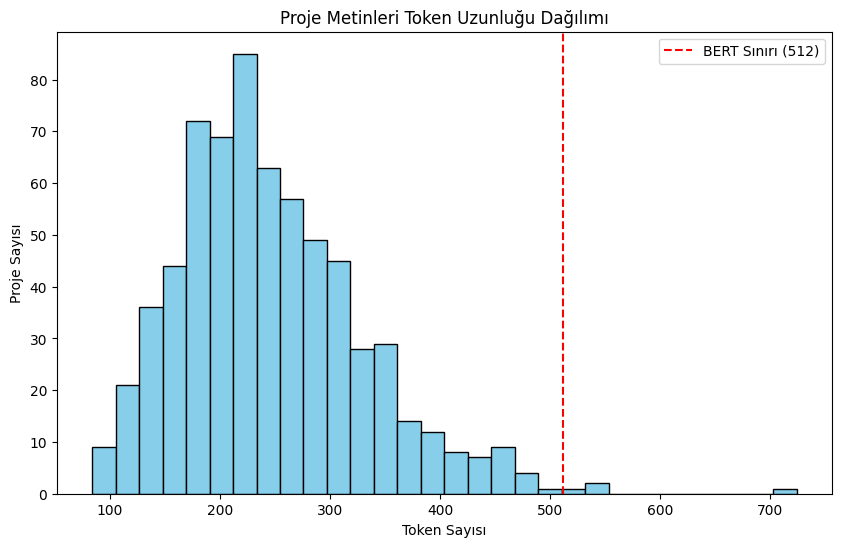

Ortalama token sayısı: 245.88288288288288
512 token'ı geçen proje sayısı: 4


In [ ]:
# Her bir satırdaki token sayısını hesapla
df['token_counts'] = df['combined_text'].apply(lambda x: len(tokenizer.encode(x, add_special_tokens=True)))

# Histogramı çiz
plt.figure(figsize=(10, 6))
plt.hist(df['token_counts'], bins=30, color='skyblue', edgecolor='black')
plt.axvline(x=512, color='red', linestyle='--', label='BERT Sınırı (512)')
plt.title('Proje Metinleri Token Uzunluğu Dağılımı')
plt.xlabel('Token Sayısı')
plt.ylabel('Proje Sayısı')
plt.legend()
plt.show()

# İstatistikleri gör
print(f"Ortalama token sayısı: {df['token_counts'].mean()}")
print(f"512 token'ı geçen proje sayısı: {(df['token_counts'] > 512).sum()}")

In [ ]:
# Embedding Üretim Fonksiyonu
def get_embeddings(text):
    # Metni tokenize et ve tensöre çevir
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=512, padding=True)

    # Inputları GPU'ya al
    inputs = {k: v.to(device) for k, v in inputs.items()}

    # Gradyan hesaplamayı kapatıyoruz (hız ve bellek için)
    with torch.no_grad():
        outputs = model(**inputs)

    # last_hidden_state: [1, token_sayisi, 768] boyutundadır
    embeddings = outputs.last_hidden_state

    # Maskeleme yaparak sadece gerçek kelimelerin ortalamasını alıyoruz (Mean Pooling)
    mask = inputs['attention_mask'].unsqueeze(-1).expand(embeddings.size()).float()
    masked_embeddings = embeddings * mask
    summed = torch.sum(masked_embeddings, 1)
    summed_mask = torch.clamp(mask.sum(1), min=1e-9)

    mean_pooled = summed / summed_mask

    # Vektörü 1D numpy dizisi olarak döndür
    return mean_pooled[0].cpu().numpy()

**Mean Pooling Neden Gerekli?** <br>
BERT modelleri her token (kelime parçası) için ayrı bir vektör üretir. Ancak iki projeyi karşılaştırabilmek için tüm metnin tek bir "imza" vektörüne ihtiyacımız vardır. Mean Pooling işlemi şu formülle her projeyi tek bir noktaya sabitler:

$$\text{Document Vector} = \frac{1}{\sum M} \sum_{i=1}^{n} (v_i \cdot M_i)$$

Burada $v_i$ kelime vektörlerini, $M_i$ ise maskeleme bilgisini temsil eder.

In [ ]:
# 1. Pandas için tqdm desteğini etkinleştiriyoruz
tqdm.pandas()

print("Embedding işlemi başlatıldı...")

# 2. .apply() yerine .progress_apply() -> Bu sayede her bir satır işlenirken bir ilerleme çubuğu ve sayaç göreceksiniz
df["embedding"] = df["combined_text"].progress_apply(lambda x: get_embeddings(x))

print("\nİşlem tamamlandı.")

# 3. Toplam veri sayısı ve vektör boyutu
total_records = len(df)
vector_dim = len(df['embedding'].iloc[0])

print(f"Toplam işlenen veri sayısı: {total_records}")
print(f"Vektör boyutu: {vector_dim}")

Embedding işlemi başlatıldı...



100%|██████████| 666/666 [00:11<00:00, 59.73it/s]


İşlem tamamlandı.
Toplam işlenen veri sayısı: 666
Vektör boyutu: 768


### Kosinüs Benzerliği (Cosine Similarity) ile Anlamsal Karşılaştırma

Kosinüs benzerliği ($\text{Cosine Similarity}$), iki vektör arasındaki açının kosinüsünü hesaplayarak
vektörlerin **yönel benzerliğini** ölçen bir metriktir. Bu yöntem, vektörlerin büyüklüğünden
bağımsız olarak anlamsal yakınlığı değerlendirmesi nedeniyle metin benzerliği problemlerinde
yaygın olarak kullanılmaktadır.

Matematiksel olarak iki vektör $\mathbf{A}$ ve $\mathbf{B}$ arasındaki kosinüs benzerliği şu şekilde tanımlanır:

$$
\text{similarity} = \cos(\theta) =
\frac{\mathbf{A} \cdot \mathbf{B}}{\|\mathbf{A}\| \|\mathbf{B}\|}
$$

Bu çalışmada:
- Metinler **BERTurk** modeli kullanılarak 768 boyutlu embedding vektörlerine dönüştürülmüştür.
- Sorgu metni ile veri kümesindeki her bir kayıt arasındaki anlamsal benzerlik,
  kosinüs benzerliği yardımıyla hesaplanmıştır.
- Elde edilen skorlar **[−1, 1]** aralığında olup, değerin 1’e yaklaşması metinlerin
  anlamsal olarak daha benzer olduğunu göstermektedir.

Sonuç olarak, en yüksek kosinüs benzerliği skoruna sahip kayıtlar,
sorgu metnine anlamsal açıdan en yakın projeler olarak raporlanmıştır.

In [ ]:
# 1. Temizleme Fonksiyonu
def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r"\s+", " ", text)          # Fazla boşluklar
    text = re.sub(r"[#%&*_=+<>]", "", text)   # Anlamsız özel karakterler
    return text.strip()

# 2. Örnek girdi
raw_query_title = "Hava Muharebesinde Otonom Savunma Algoritmasının Geliştirilmesi"

raw_query_abstract = (
    "Bu çalışma kapsamında, temel hava muharebesi manevraları kullanılarak "
    "birebir muharebeler için otonom savunma algoritması geliştirilmiştir. "
    "Algoritma, hedef hava aracı ile beklenmedik bir şekilde karşılaşıldığı durumlarda "
    "saldırı üstünlüğünün sağlanması için en uygun muharebe manevrasını seçmeyi sağlamaktadır. "
    "Algoritmanın test edilmesi amacıyla saldıran ve savunan uçaklar için doğrusal olmayan "
    "dinamik modeller kullanılmıştır. Algoritmada manevra seçimi için temel savaş "
    "manevralarını içeren manevra kütüphanesinden uygun manevrayı seçecek kural tabanlı "
    "bir yapı önerilmiştir. MATLAB/Simulink ortamında yapılan benzetim çalışmaları ile "
    "algoritmanın başarımı test edilmiş ve sonuçlar gösterilmiştir."
)

raw_query_keywords = "bire-bir hava muharebesi, kural tabanlı yöntem, temel hava muharebe manevraları."

# 3. Verileri temizliyoruz
query_title = clean_text(raw_query_title)
query_abstract = clean_text(raw_query_abstract)
query_keywords = clean_text(raw_query_keywords)

# 4. Verileri birleştiriyoruz (combined_text mantığı)
query_text = f"{query_title} {query_abstract} {query_keywords}"

# 5. Aynı model ile Embedding üretimi
query_vector = get_embeddings(query_text).reshape(1, -1)

# 6. Karşılaştırma
corpus_embeddings = np.array(df["embedding"].tolist())
similarity_scores = cosine_similarity(query_vector, corpus_embeddings)[0]

# 7. Sonuçları raporlama
df["similarity_score"] = similarity_scores
top_results = df.sort_values(by="similarity_score", ascending=False)

print("Benzerlik Sonucu:")
with pd.option_context('display.max_colwidth', None):
    display(top_results[["Year","Title_TR", "Abstract_TR","similarity_score"]].head(5))

Benzerlik Sonucu:


,Year,Title_TR,Abstract_TR,similarity_score
2,2020-2021,Hava Muharebesinde Otonom Savunma Algoritmasının Geliştirilmesi,"Bu çalışma kapsamında, temel hava muharebesi manevraları kullanılarak birebir muharebeler için otonom savunma algoritması geliştirilmiştir. Algoritma, hedef hava aracı ile beklenmedik bir şekilde karşılaşıldığı durumlarda saldırı üstünlüğünün sağlanması için en uygun muharebe manevrasını seçmeyi sağlamaktadır. Algoritmanın test edilmesi amacıyla saldıran ve savunan uçaklar için doğrusal olmayan dinamik modeller kullanılmıştır. Algoritmada manevra seçimi için temel savaş manevralarını içeren manevra kütüphanesinden uygun manevrayı seçecek kural tabanlı bir yapı önerilmiştir. MATLAB/Simulink ortamında yapılan benzetim çalışmaları ile algoritmanın başarımı test edilmiş ve sonuçlar gösterilmiştir.",1.000000
478,2023-2024,Hava Muharebesinde Bulanık Mantık ile Karar,"Hava muharebeleri, saldırı ve savunma manevralarının dengeli bir şekilde yapıldığı karmaşık stratejilere dayanmaktadır. Bu projede, hava muharebelerinde otonom karar alma yeteneğini artırmak için oyun teorisi, bulanık mantık ve dinamik programlama gibi ileri düzey tekniklerin birleşiminden oluşan bir algoritma geliştirilmesi hedeflenmektedir. Geliştirilecek olan algoritma, hava muharebelerinde bilinçli kararlar alabilen otonom sistemlerin geliştirilmesine odaklanmaktadır. Bu amaçla, geliştirilen algoritma simülasyon ortamında test edilecek ve başarı oranı ölçülecektir. Algoritmanın performansı, çeşitli simüle edilmiş muharebe senaryoları üzerinde test edilerek değerlendirilecektir. Başarı metrikleri arasında, misyon başarı oranları, kaynak kullanım verimliliği ve değişen ortamlara uygunluk gibi faktörler bulunacaktır. Bu çalışma, hava muharebelerinde otonom sistemlerin karar alma yeteneğini artırmak için kullanılabilecek yeni ve etkili bir yaklaşım sunmayı amaçlamaktadır.",0.968412
479,2023-2024,"Hava Muharebesinde Oyun Teorisi, Bulanık Mantık ve Dinamik Programlama Kullanarak Karar Verme Algoritmasının Uygulanması ve Analizi","Bu çalışmada hava muharebesinde askeri pilotların başarı oranını artırmak için eğitim amaçlı kullanılmak üzere hava araçlarının aerodinamik yapıları göz önünde bulundurularak Unity oyun motorunda simülasyon ortamı hazırlanmıştır. Bu ortamda eğitim görmekte olan pilotlarla yarışacak, düşman pilot olarak görev alacak, pilotların manevralarını analiz ederek sürekli kendi stratejisini belirleyecek bir yapay zekâ modeli geliştirilmiştir. Yapay zekâ modelinin tasarımında derin öğrenme ve takviyeli öğrenme tekniklerini birleştiren Derin Q Ağları (DQN) kullanılmıştır. Bu alanda belirttiğimiz tekniklerle, geliştirdiğimiz eğitim simülasyon ortamının bir araya getirilmesi çalışmamızın temel katkısıdır. Geliştirilen simülasyon sistemi ve DQN tabanlı yapay zekâ modeli, hava muharebesi eğitimlerinde kullanılacak bir eğitim aracının temellerini oluşturmuştur.",0.960303
627,2023-2024,Temsili Tehdit Modellerinin Yapay Zeka Öğrenmesi Kullanılarak Geliştirilmesi ve Modellenmesi,"Savunma sanayiinde son yıllardaki teknolojik gelişmeler ile birlikte, gerçek olayların olmadan önce tahmini için bilgisayar ortamında simülasyonunun yapılması kaçınılmaz olmuştur. Geliştirilen farklı ve olası tehdit modelleri ile olaylar olmadan önce alınabilecek önlemlerin tahmini ve geliştirilmesi çalışmaları son yıllarda önemli araştırma konularından biridir. Bu çalışmada, pekiştirmeli öğrenme modeli kullanılarak, açık kaynaklı olan F-16 uçuş dinamik modeli ile bir uçağın füze atış sonrası mevcut konumundan hızlıca uzaklaşmak ve/veya kendisine yapılan füze atışı sonrası füze kaçış yapabilmek için gerekli manevrayı yapabilmesini sağlamak hedeflenmiştir. Eğitilen F16 yapay zeka modelinin farklı durumlara göre hareket etmesini sağlamak için SAC (Soft Actor-Critic) ve PPO (Proximal Policy Optimization) derin öğrenme algoritmaları kullanılmıştır. Model, JSBSim çevresi ile belirli durumlarda pozitif ve negatif ödül değerleri alarak eğitilmiş ve farklı manevralar gerçekleştir

In [ ]:
print("En Az Benzer Sonuçlar:")
with pd.option_context('display.max_colwidth', None):
    display(top_results[["Year","Title_TR", "Abstract_TR","similarity_score"]].tail(5))

En Az Benzer Sonuçlar:


,Year,Title_TR,Abstract_TR,similarity_score
247,2022-2023,3D Printer Teknolojisi Kullanılarak Elektronik Harp Sistemlerinde Kullanılmakta olan Chaff/Flare Magazine Sarf Malzemesinin Üretilmesi ve Test Edilmesi,"Chaff/flare isi ve radar güdümlü füzelerin hedefini saptirmak için kullanılan önleme sistemleridir. Bu sistemlerin geneline karşi tedbir sistemleri denir. Magazine yani fişek haznesi chaff ve flare sarf malzemelerinin yerleştirileceği mekanizmadir. Önerilen proje kapsaminda konvansiyonel yöntemlerin uzun ve zahmetli üretim sürecine karşilik, fişek haznesinin eklemeli imalat (Eİ) teknolojisi ile üretilerek imalat süreçlerinin daha etkin hale getirilmesi amaçlanmaktadir. 3 boyutlu (3B) tasarim verisinden yola çikarak, herhangi bir kalip, takim, fikstür vb. ihtiyaç olmadan imalat işlemini mümkün kilan Eİ teknolojisi gerek zaman gerekse malzeme kullanimi açisindan son derece verimli çözümler sunmaktadir. Bu proje kapsaminda bu parçanin zamana bağli termal analizleri, yapisal analizleri ve imalat aşamasindaki kalite parametrelerinin optimizasyonu üzerinde durulmuştur. Bu analizlerin çiktilari incelenerek en uygun malzemenin seçilerek malzemenin üretiminde en düşük boyutsal sapma ile parçanin üretilmesi hedeflenmektedir.",0.874086
289,2022-2023,Helikopter Aviyonik Bay için Solar Load Modellemesi,"Bu çalişmada, mevcut analiz yazilimlarinda güneş yükünün modellenmesindeki eksikliklerin giderilmesi amaçlanmiştir. Güneş yükünün irtifayla değişimini hesaplayan çeşitli yöntemler sunulmuş, hesaplamalarin UDF araciliği ile Fluent üzerinde diş akiş hacmi olmadan uygulanmasi sağlanmiştir. Ayrica UDF, hesaplanan güneş yükünü yüzeylerin eğimini dikkate alarak ve gölgede kalma durumunu kontrol ederek uygulamaktadir. Bunun dişinda hava aracinin dişinda oluşan taşinim isi transferini de hesaplamalara dahil etmek için uygun isi transferi korelasyonlari önerilmiştir. Bu çalişmayla hava araçlarinda güneş yükünün modellenmesi kolaylaştirilmiş ve irtifa faktörünün dikkate alinmasi sağlanarak güneş yükü modellemesi daha gerçekçi hale getirilmiştir.",0.871416
358,2022-2023,Süpersonik Uçuşta Sıcaklığın Diverjans Üzerindeki Etkisi,"Flutter, aerodinamik kuvvetler ile yapisal dinamikler arasinda bir bağlanti olduğunda uçaklarda ve diğer yapilarda meydana gelebilecek bir olgudur. Aerotermoelastisite, aerodinamik, isi transferi ve yapisal dinamikler arasindaki etkileşimlerle ilgilenen bir mühendislik dalidir. Bu çalişmada, süperonik hizlarda sicakliğin diverjans üzerindeki etkisi üç boyutlu F-16 kanat modeli için incelenmiştir. Analizler Ansys paket programi vasitasiyla yapilmiştir. Sicak, soğuk ve normal gün için elde edilen aeroelastik veriler literatürdeki sonuçlarla karşilaştirilmiş ve sonuçlar doğrulanmiştir.",0.866640
318,2022-2023,Kurum İçi Girişimcilik Kültürünün Yaygınlaştırılması ve Destekleyici Faaliyetlerin Geliştirilmesi,"Bu çalişmada TUSAŞ’ta kurum içi girişimcilik fikirlerinin değerlendirilmesi adina bir model tasarlanmiştir. Literatür çalişmasi yapilarak yurt içinde ve dişinda başarili olan modeller incelenmiştir. İncelenen bazi modellerin birbirleri ile karşilaştirilmasi için SWOT analizleri yapilmiştir. Hizlandirma programi olarak kurgulanan modelde, girişimcilik fikirlerini değerlendirmek için ön değerlendirme, mülakat, teknik değerlendirme ve nihai değerlendirme olmak üzere dört ayri süreç tasarlanmiştir. Ön değerlendirme, mülakat ve teknik değerlendirme aşamalari için formlar hazirlanmiştir. Modelin eleme aşamalarinda kullanilacak olan değerlendirme kriterlerinin puanlamasi için yorumlanmasi ve proje odakli olmasi öngörülmüştür.",0.864508
527,2023-2024,Karbon Prepreg ve Film Adhesive Malzemelerin Farklı Ortamlara Bağlı Olarak Yaşlanma Özelliklerinin İncelenmesi,"Bu çalışma, karbon prepreg ve film adhesive malzemelerin farklı ortam koşullarında yaşlanma özelliklerini araştırmaktadır. Karbon prepregler, yüksek mukavemet/ağırlık oranları, iyi enerji emme kapasiteleri ve uzun hizmet ömürleri nedeniyle havacılık sektörü başta olmak üzere

In [ ]:
print(df['Title_TR'].iloc[2],"/",df["Year"].iloc[2],"\n")
df["Abstract_TR"].iloc[2]

Hava Muharebesinde Otonom Savunma Algoritmasının Geliştirilmesi / 2020-2021 



'Bu çalışma kapsamında, temel hava muharebesi manevraları kullanılarak birebir muharebeler için otonom savunma algoritması geliştirilmiştir. Algoritma, hedef hava aracı ile beklenmedik bir şekilde karşılaşıldığı durumlarda saldırı üstünlüğünün sağlanması için en uygun muharebe manevrasını seçmeyi sağlamaktadır. Algoritmanın test edilmesi amacıyla saldıran ve savunan uçaklar için doğrusal olmayan dinamik modeller kullanılmıştır. Algoritmada manevra seçimi için temel savaş manevralarını içeren manevra kütüphanesinden uygun manevrayı seçecek kural tabanlı bir yapı önerilmiştir. MATLAB/Simulink ortamında yapılan benzetim çalışmaları ile algoritmanın başarımı test edilmiş ve sonuçlar gösterilmiştir.'

In [ ]:
print(df['Title_TR'].iloc[478],"/",df["Year"].iloc[478],"\n")
df["Abstract_TR"].iloc[478]

Hava Muharebesinde Bulanık Mantık ile Karar / 2023-2024 



'Hava muharebeleri, saldırı ve savunma manevralarının dengeli bir şekilde yapıldığı karmaşık stratejilere dayanmaktadır. Bu projede, hava muharebelerinde otonom karar alma yeteneğini artırmak için oyun teorisi, bulanık mantık ve dinamik programlama gibi ileri düzey tekniklerin birleşiminden oluşan bir algoritma geliştirilmesi hedeflenmektedir. Geliştirilecek olan algoritma, hava muharebelerinde bilinçli kararlar alabilen otonom sistemlerin geliştirilmesine odaklanmaktadır. Bu amaçla, geliştirilen algoritma simülasyon ortamında test edilecek ve başarı oranı ölçülecektir. Algoritmanın performansı, çeşitli simüle edilmiş muharebe senaryoları üzerinde test edilerek değerlendirilecektir. Başarı metrikleri arasında, misyon başarı oranları, kaynak kullanım verimliliği ve değişen ortamlara uygunluk gibi faktörler bulunacaktır. Bu çalışma, hava muharebelerinde otonom sistemlerin karar alma yeteneğini artırmak için kullanılabilecek yeni ve etkili bir yaklaşım sunmayı amaçlamaktadır.'

In [ ]:
print(df['Title_TR'].iloc[479],"/",df["Year"].iloc[479],"\n")
df["Abstract_TR"].iloc[479]

Hava Muharebesinde Oyun Teorisi, Bulanık Mantık ve Dinamik Programlama Kullanarak Karar Verme Algoritmasının Uygulanması ve Analizi / 2023-2024 



'Bu çalışmada hava muharebesinde askeri pilotların başarı oranını artırmak için eğitim amaçlı kullanılmak üzere hava araçlarının aerodinamik yapıları göz önünde bulundurularak Unity oyun motorunda simülasyon ortamı hazırlanmıştır. Bu ortamda eğitim görmekte olan pilotlarla yarışacak, düşman pilot olarak görev alacak, pilotların manevralarını analiz ederek sürekli kendi stratejisini belirleyecek bir yapay zekâ modeli geliştirilmiştir. Yapay zekâ modelinin tasarımında derin öğrenme ve takviyeli öğrenme tekniklerini birleştiren Derin Q Ağları (DQN) kullanılmıştır. Bu alanda belirttiğimiz tekniklerle, geliştirdiğimiz eğitim simülasyon ortamının bir araya getirilmesi çalışmamızın temel katkısıdır. Geliştirilen simülasyon sistemi ve DQN tabanlı yapay zekâ modeli, hava muharebesi eğitimlerinde kullanılacak bir eğitim aracının temellerini oluşturmuştur.'

In [ ]:
print(df['Title_TR'].iloc[627],"/",df["Year"].iloc[627],"\n")
df["Abstract_TR"].iloc[627]

Temsili Tehdit Modellerinin Yapay Zeka Öğrenmesi Kullanılarak Geliştirilmesi ve Modellenmesi / 2023-2024 



'Savunma sanayiinde son yıllardaki teknolojik gelişmeler ile birlikte, gerçek olayların olmadan önce tahmini için bilgisayar ortamında simülasyonunun yapılması kaçınılmaz olmuştur. Geliştirilen farklı ve olası tehdit modelleri ile olaylar olmadan önce alınabilecek önlemlerin tahmini ve geliştirilmesi çalışmaları son yıllarda önemli araştırma konularından biridir. Bu çalışmada, pekiştirmeli öğrenme modeli kullanılarak, açık kaynaklı olan F-16 uçuş dinamik modeli ile bir uçağın füze atış sonrası mevcut konumundan hızlıca uzaklaşmak ve/veya kendisine yapılan füze atışı sonrası füze kaçış yapabilmek için gerekli manevrayı yapabilmesini sağlamak hedeflenmiştir. Eğitilen F16 yapay zeka modelinin farklı durumlara göre hareket etmesini sağlamak için SAC (Soft Actor-Critic) ve PPO (Proximal Policy Optimization) derin öğrenme algoritmaları kullanılmıştır. Model, JSBSim çevresi ile belirli durumlarda pozitif ve negatif ödül değerleri alarak eğitilmiş ve farklı manevralar gerçekleştirmek üzere pro

In [ ]:
print(df['Title_TR'].iloc[386],"/",df["Year"].iloc[386],"\n")
df["Abstract_TR"].iloc[386]

6 Serbestlik Dereceli Uçak Modeli ile Manevra Kontrolü / 2023-2024 



"Bu araştırma projesi, uçakların temel ve akrobatik manevralar sırasında kontrolü için kontrolcü tasarımı ve simülasyonunu kapsamaktadır. İlk olarak, altı serbestlik derecesinde hareket denklemleri kullanılarak bir uçak modeli oluşturulmuş ve MATLAB/Simulink programı kullanılarak aerodinamik, itki ve atmosfer kütüphaneleri entegre edilmiştir. Lineer olmayan denklemler lineerleştirilmiş, dinamik modlar elde edilmiş ve veriler FlightGear'da görselleştirilmiştir. Çalışma, SİHA tipi uçakların artan önemi doğrultusunda, akrobatik manevralar için gerekli olan kontrolcü ve manevra planlamasına odaklanmaktadır. Uçağın dinamik davranışını yönetebilen ve yüksek ivmeli manevraları gerçekleştirebilen kontrolcü seçilmiş ve entegre edilmiştir. Sonraki aşamalarda, bu kontrolcü optimize edilerek stabilite ve manevra kabiliyeti artırılmış ve güvenilir manevra gerçekleştirmesi için simülasyonlar yapılmıştır. Bu çalışma, uçakların karmaşık ve dinamik ortamlarda çevik manevralar gerçekleştirebilmesi için 

In [ ]:
len(top_results)

666

In [ ]:
print(df['Title_TR'].iloc[318],"/",df["Year"].iloc[318],"\n")
df["Abstract_TR"].iloc[318]

Kurum İçi Girişimcilik Kültürünün Yaygınlaştırılması ve Destekleyici Faaliyetlerin Geliştirilmesi / 2022-2023 



'Bu çalişmada TUSAŞ’ta kurum içi girişimcilik fikirlerinin değerlendirilmesi adina bir model tasarlanmiştir. Literatür çalişmasi yapilarak yurt içinde ve dişinda başarili olan modeller incelenmiştir. İncelenen bazi modellerin birbirleri ile karşilaştirilmasi için SWOT analizleri yapilmiştir. Hizlandirma programi olarak kurgulanan modelde, girişimcilik fikirlerini değerlendirmek için ön değerlendirme, mülakat, teknik değerlendirme ve nihai değerlendirme olmak üzere dört ayri süreç tasarlanmiştir. Ön değerlendirme, mülakat ve teknik değerlendirme aşamalari için formlar hazirlanmiştir. Modelin eleme aşamalarinda kullanilacak olan değerlendirme kriterlerinin puanlamasi için yorumlanmasi ve proje odakli olmasi öngörülmüştür.'